# Cashflow Prediction on Kaggle Personal Finance Dataset

This notebook loads the `khushikyad001/personal-finance-tracker-dataset` using `kagglehub`.
Since this dataset is pre-aggregated per month, we can map its columns directly to what
our Prophet + LightGBM `Forecaster` expects and predict a user's cashflow without needing
to run the `Categorizer` and `FeatureEngineer`.

In [1]:
import os
import warnings
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import our custom Forecaster from the src directory
import sys
from pathlib import Path

# Add src to Python path so we can import our pipeline components
src_path = Path(os.getcwd()).parent / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from forecaster import CashflowForecaster

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_theme(style="whitegrid", palette="muted")

## 1. Load Dataset

In [2]:
print("Downloading dataset...")
path = kagglehub.dataset_download("khushikyad001/personal-finance-tracker-dataset")
print("Path to dataset files:", path)

# Find the csv file
csv_file = None
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            csv_file = os.path.join(root, file)
            break

if not csv_file:
    raise FileNotFoundError("Could not find CSV file in downloaded Kaggle dataset.")

df = pd.read_csv(csv_file)
print(f"Dataset loaded with {len(df)} rows.")

# Ensure date is a datetime object
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['user_id', 'date'])

df.head()

Path to dataset files: C:\Users\Admin\.cache\kagglehub\datasets\khushikyad001\personal-finance-tracker-dataset\versions\1
Dataset loaded with 3000 rows.


,date,user_id,monthly_income,monthly_expense_total,savings_rate,budget_goal,financial_scenario,credit_score,debt_to_income_ratio,loan_payment,...,discretionary_spending,essential_spending,income_type,rent_or_mortgage,category,cash_flow_status,financial_advice_score,financial_stress_level,actual_savings,savings_goal_met
1749,2019-09-28,1000,3374.92,4718.17,0.38,3863.29,inflation,677.0,0.36,527.88,...,456.40,2245.69,Freelance,1521.30,Dining Out,Negative,31.7,Low,0.00,0
1214,2020-02-25,1000,3381.06,2088.04,0.35,2127.41,inflation,616.0,0.52,914.31,...,430.48,2091.79,Salary,1140.20,Rent,Positive,66.3,Low,1293.02,0
1965,2022-09-12,1000,2532.54,2400.73,0.14,2374.16,normal,580.0,0.43,599.30,...,500.86,1689.52,Freelance,1632.85,Insurance,Positive,84.4,Low,131.81,0
1084,2019-05-01,1001,4301.38,1671.02,0.15,2845.22,inflation,760.0,0.53,825.80,...,541.16,1545.27,Salary,1495.34,Dining Out,Neutral,49.2,Low,2630.36,0
1452,2019-12-27,1001,5343.85,4082.16,0.13,2101.12,normal,687.0,0.27,692.51,...,193.65,3263.26,Salary,1502.98,Rent,Positive,49.2,Medium,1261.69,0


## 2. Map Kaggle Schema to Pipeline Schema

Our pipeline expects a DataFrame with a monthly `period`, `total_inflow`, `total_outflow`, and `net_cashflow`.
We'll map the Kaggle dataset's columns to these names. We will also include tabular features to help LightGBM.

In [3]:
def map_to_pipeline_schema(df: pd.DataFrame) -> pd.DataFrame:
    """Maps the Kaggle finance dataset to our pipeline's expected schema."""
    mapped = df.copy()
    
    # Core expected features
    mapped = mapped.rename(columns={
        "date": "period",
        "monthly_income": "total_inflow",
        "monthly_expense_total": "total_outflow",
        "loan_payment": "emi_amount",
        "rent_or_mortgage": "rent_amount",
        "discretionary_spending": "discretionary_amount"
    })
    
    # Calculate net cashflow
    mapped["net_cashflow"] = mapped["total_inflow"] - mapped["total_outflow"]
    
    # Create fixed obligation ratio (similar to our feature engineer)
    mapped["fixed_obligations"] = mapped["emi_amount"] + mapped["rent_amount"]
    mapped["fixed_obligation_ratio"] = mapped["fixed_obligations"] / mapped["total_inflow"]
    
    return mapped

mapped_df = map_to_pipeline_schema(df)
mapped_df.head()

,period,user_id,total_inflow,total_outflow,savings_rate,budget_goal,financial_scenario,credit_score,debt_to_income_ratio,emi_amount,...,rent_amount,category,cash_flow_status,financial_advice_score,financial_stress_level,actual_savings,savings_goal_met,net_cashflow,fixed_obligations,fixed_obligation_ratio
1749,2019-09-28,1000,3374.92,4718.17,0.38,3863.29,inflation,677.0,0.36,527.88,...,1521.30,Dining Out,Negative,31.7,Low,0.00,0,-1343.25,2049.18,0.607179
1214,2020-02-25,1000,3381.06,2088.04,0.35,2127.41,inflation,616.0,0.52,914.31,...,1140.20,Rent,Positive,66.3,Low,1293.02,0,1293.02,2054.51,0.607653
1965,2022-09-12,1000,2532.54,2400.73,0.14,2374.16,normal,580.0,0.43,599.30,...,1632.85,Insurance,Positive,84.4,Low,131.81,0,131.81,2232.15,0.881388
1084,2019-05-01,1001,4301.38,1671.02,0.15,2845.22,inflation,760.0,0.53,825.80,...,1495.34,Dining Out,Neutral,49.2,Low,2630.36,0,2630.36,2321.14,0.539627
1452,2019-12-27,1001,5343.85,4082.16,0.13,2101.12,normal,687.0,0.27,692.51,...,1502.98,Rent,Positive,49.2,Medium,1261.69,0,1261.69,2195.49,0.410844


## 3. Exploratory Data Analysis (EDA)

Let's explore how cashflow looks across different financial scenarios.

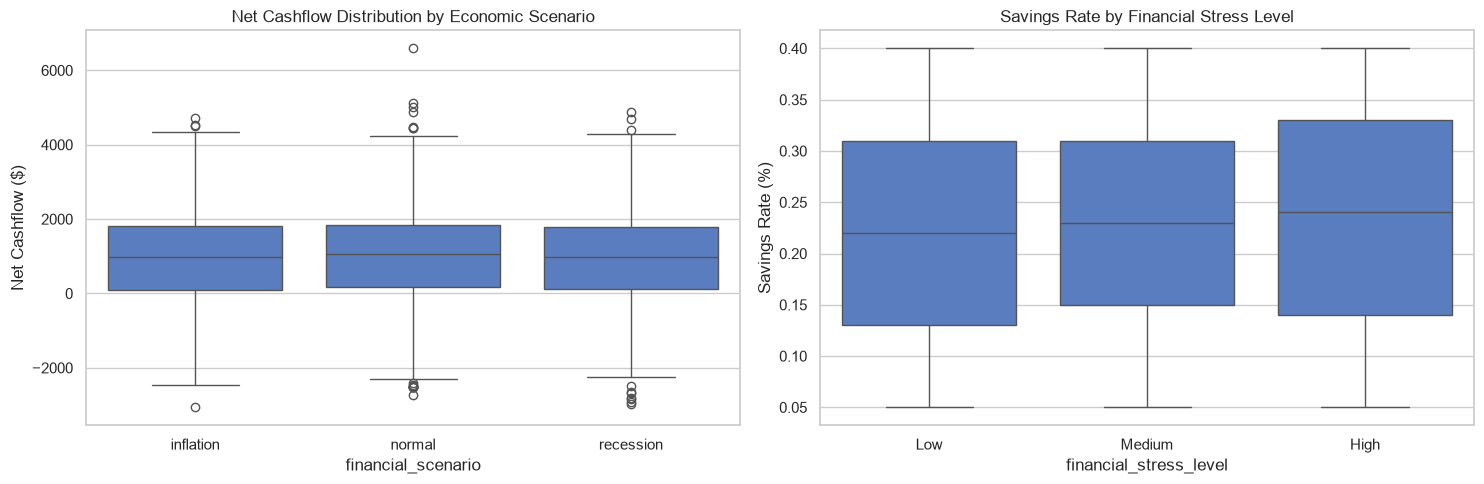

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Cashflow by Scenario
sns.boxplot(data=mapped_df, x='financial_scenario', y='net_cashflow', ax=axes[0])
axes[0].set_title('Net Cashflow Distribution by Economic Scenario')
axes[0].set_ylabel('Net Cashflow ($)')

# Plot 2: Financial Stress vs Savings Rate
sns.boxplot(data=mapped_df, x='financial_stress_level', y='savings_rate', ax=axes[1], 
            order=['Low', 'Medium', 'High'])
axes[1].set_title('Savings Rate by Financial Stress Level')
axes[1].set_ylabel('Savings Rate (%)')

plt.tight_layout()
plt.show()

## 4. Train Cashflow Forecaster

Let's pick a single user who has a good amount of historical data, and run our `CashflowForecaster` on them.

Aggregating dataset across all users by period to create an 'average user' profile...
Created Aggregate_Average with 60 months of data.


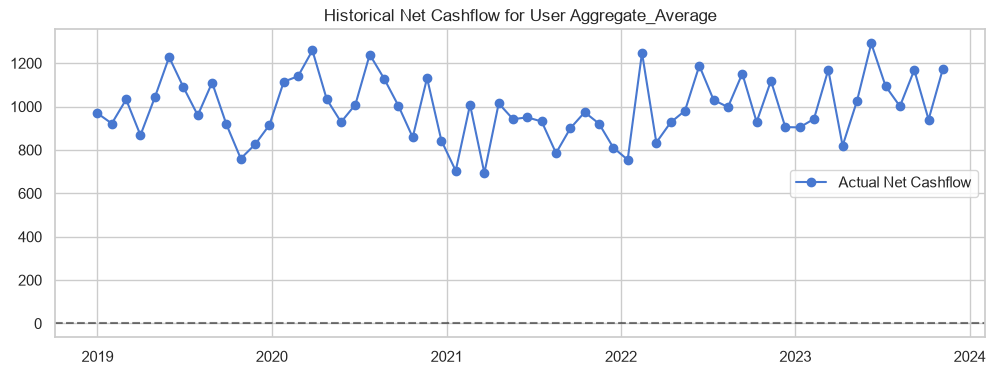

In [5]:
# Create an "aggregate user" profile because individual users have insufficient historical data (max 11 months).
# We need at least 20 months for the chronological train/val/test split (60/20/20).
print("Aggregating dataset across all users by period to create an 'average user' profile...")
import numpy as np
numeric_cols = mapped_df.select_dtypes(include='number').columns.drop(['user_id', 'savings_goal_met'], errors='ignore')
user_df = mapped_df.groupby('period')[numeric_cols].mean().reset_index()

# Ensure period is timestamp for Prophet
user_df['period'] = pd.to_datetime(user_df['period'])
user_df = user_df.sort_values('period')

target_user = "Aggregate_Average"
print(f"Created {target_user} with {len(user_df)} months of data.")

# Plot their historical net cashflow
plt.figure(figsize=(12, 4))
plt.plot(user_df['period'], user_df['net_cashflow'], marker='o', label='Actual Net Cashflow')
plt.title(f"Historical Net Cashflow for User {target_user}")
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

Now we initialize and train the dual-engine model!

Now we initialize our dual-engine Cashflow Forecaster!

In [6]:
forecaster = CashflowForecaster(prophet_weight=0.5, lgbm_weight=0.5)

## 4b. Hyperparameter Tuning (Optuna + MLflow)

Instead of a basic fit, we'll use `tune_and_fit` which triggers a 5-fold TimeSeries cross-validation 
Optuna study to find the best LightGBM hyperparameters for this specific user. 
Everything is automatically logged to MLflow!

In [7]:
from ml_trainer import tune_cashflow_forecaster

print(f"Running Optuna tuning for {target_user}...")
# 1. Tuning Step
best_params = tune_cashflow_forecaster(
    df=user_df, 
    n_trials=20, 
    run_name=f"kaggle_{target_user}_tuning"
)
print("\nTuning Complete! Best LightGBM Parameters found:")
print(best_params)

# 2. Training Step (Separate)
# We update the forecaster with the best params and fit it explicitly
forecaster = CashflowForecaster(prophet_weight=0.5, lgbm_weight=0.5, lgbm_params=best_params)
forecaster.fit(user_df)
print("\nModel training complete.")

Running Optuna tuning for Aggregate_Average...

[OPTUNA] Starting 5-Fold Walk-Forward CV Search | 20 trials remaining...


13:41:57 - cmdstanpy - INFO - Chain [1] start processing
13:41:58 - cmdstanpy - INFO - Chain [1] done processing
13:42:00 - cmdstanpy - INFO - Chain [1] start processing
13:42:01 - cmdstanpy - INFO - Chain [1] done processing
13:42:01 - cmdstanpy - INFO - Chain [1] start processing
13:42:02 - cmdstanpy - INFO - Chain [1] done processing
13:42:02 - cmdstanpy - INFO - Chain [1] start processing
13:42:04 - cmdstanpy - INFO - Chain [1] done processing
13:42:04 - cmdstanpy - INFO - Chain [1] start processing
13:42:05 - cmdstanpy - INFO - Chain [1] done processing


Trial 000 | Mean CV RMSE: 142 | Folds: [158, 182, 142, 44, 186]


2026/07/15 13:42:07 INFO mlflow.tracking.fluent: Experiment with name 'kaggle_Aggregate_Average_tuning_tuning' does not exist. Creating a new experiment.
13:42:07 - cmdstanpy - INFO - Chain [1] start processing
13:42:08 - cmdstanpy - INFO - Chain [1] done processing
13:42:09 - cmdstanpy - INFO - Chain [1] start processing
13:42:10 - cmdstanpy - INFO - Chain [1] done processing
13:42:10 - cmdstanpy - INFO - Chain [1] start processing
13:42:11 - cmdstanpy - INFO - Chain [1] done processing
13:42:12 - cmdstanpy - INFO - Chain [1] start processing
13:42:14 - cmdstanpy - INFO - Chain [1] done processing
13:42:15 - cmdstanpy - INFO - Chain [1] start processing
13:42:16 - cmdstanpy - INFO - Chain [1] done processing


Trial 001 | Mean CV RMSE: 134 | Folds: [150, 168, 138, 45, 170]


...

Trial 007 | Mean CV RMSE: 129 | Folds: [144, 154, 138, 44, 164]


13:43:04 - cmdstanpy - INFO - Chain [1] start processing
13:43:05 - cmdstanpy - INFO - Chain [1] done processing
13:43:05 - cmdstanpy - INFO - Chain [1] start processing
13:43:06 - cmdstanpy - INFO - Chain [1] done processing
13:43:07 - cmdstanpy - INFO - Chain [1] start processing
13:43:07 - cmdstanpy - INFO - Chain [1] done processing
13:43:08 - cmdstanpy - INFO - Chain [1] start processing
13:43:09 - cmdstanpy - INFO - Chain [1] done processing
13:43:09 - cmdstanpy - INFO - Chain [1] start processing
13:43:10 - cmdstanpy - INFO - Chain [1] done processing
13:43:11 - cmdstanpy - INFO - Chain [1] start processing
13:43:12 - cmdstanpy - INFO - Chain [1] done processing
13:43:12 - cmdstanpy - INFO - Chain [1] start processing
13:43:13 - cmdstanpy - INFO - Chain [1] done processing
13:43:14 - cmdstanpy - INFO - Chain [1] start processing
13:43:15 - cmdstanpy - INFO - Chain [1] done processing
13:43:16 - cmdstanpy - INFO - Chain [1] start processing
13:43:17 - cmdstanpy - INFO - Chain [1]

[OPTUNA] Best trial #7 — Mean CV RMSE: 129

Tuning Complete! Best LightGBM Parameters found:
{'learning_rate': 0.014772754066911016, 'num_leaves': 49, 'max_depth': 8, 'min_child_samples': 1, 'subsample': 0.8930989505142994, 'colsample_bytree': 0.5872389039903306, 'reg_alpha': 0.0019303275335063566, 'reg_lambda': 0.23560869062939527, 'n_estimators': 500, 'random_state': 42, 'n_jobs': -1}


13:43:22 - cmdstanpy - INFO - Chain [1] start processing
13:43:23 - cmdstanpy - INFO - Chain [1] done processing



Model training complete.


## 5. Predict the Next 6 Months

Let's forecast what this user's cashflow will look like for the next 6 months.

In [8]:
# Predict for multiple horizons: 3, 6, 9, and 12 months
from IPython.display import display
horizons = [3, 6, 9, 12]
forecasts = {}

for h in horizons:
    print(f"--- Forecasting {h} months ahead ---")
    forecast_df = forecaster.predict(horizon=h)
    forecasts[h] = forecast_df
    
    # Display the results for this horizon
    display(forecast_df.head(h))
    print("\n")


--- Forecasting 3 months ahead ---


,period,forecast,lower_p10,upper_p90,prophet_forecast,lgbm_forecast
0,2023-12-01,937.659059,799.646579,1075.671539,870.407808,1004.91031
1,2024-01-01,971.909955,833.897475,1109.922435,938.909599,1004.91031
2,2024-02-01,998.455382,860.442902,1136.467862,992.000453,1004.91031




--- Forecasting 6 months ahead ---


,period,forecast,lower_p10,upper_p90,prophet_forecast,lgbm_forecast
0,2023-12-01,937.659059,799.646579,1075.671539,870.407808,1004.91031
1,2024-01-01,971.909955,833.897475,1109.922435,938.909599,1004.91031
2,2024-02-01,998.455382,860.442902,1136.467862,992.000453,1004.91031
3,2024-03-01,1041.432693,903.420214,1179.445173,1077.955076,1004.91031
4,2024-04-01,958.932563,820.920084,1096.945043,912.954816,1004.91031
5,2024-05-01,1027.871645,889.859165,1165.884125,1050.832980,1004.91031




--- Forecasting 9 months ahead ---


,period,forecast,lower_p10,upper_p90,prophet_forecast,lgbm_forecast
0,2023-12-01,937.659059,799.646579,1075.671539,870.407808,1004.91031
1,2024-01-01,971.909955,833.897475,1109.922435,938.909599,1004.91031
2,2024-02-01,998.455382,860.442902,1136.467862,992.000453,1004.91031
3,2024-03-01,1041.432693,903.420214,1179.445173,1077.955076,1004.91031
4,2024-04-01,958.932563,820.920084,1096.945043,912.954816,1004.91031
5,2024-05-01,1027.871645,889.859165,1165.884125,1050.832980,1004.91031
6,2024-06-01,1082.427270,944.414790,1220.439750,1159.944229,1004.91031
7,2024-07-01,997.372363,859.359883,1135.384843,989.834415,1004.91031
8,2024-08-01,1007.494980,869.482500,1145.507459,1010.079649,1004.91031




--- Forecasting 12 months ahead ---


,period,forecast,lower_p10,upper_p90,prophet_forecast,lgbm_forecast
0,2023-12-01,937.659059,799.646579,1075.671539,870.407808,1004.91031
1,2024-01-01,971.909955,833.897475,1109.922435,938.909599,1004.91031
2,2024-02-01,998.455382,860.442902,1136.467862,992.000453,1004.91031
3,2024-03-01,1041.432693,903.420214,1179.445173,1077.955076,1004.91031
4,2024-04-01,958.932563,820.920084,1096.945043,912.954816,1004.91031
5,2024-05-01,1027.871645,889.859165,1165.884125,1050.832980,1004.91031
6,2024-06-01,1082.427270,944.414790,1220.439750,1159.944229,1004.91031
7,2024-07-01,997.372363,859.359883,1135.384843,989.834415,1004.91031
8,2024-08-01,1007.494980,869.482500,1145.507459,1010.079649,1004.91031
9,2024-09-01,1087.761499,949.749019,1225.773979,1170.612687,1004.91031


### Plotting the Forecast

Let's visualize the historical data alongside the Prophet/LightGBM ensemble forecast.

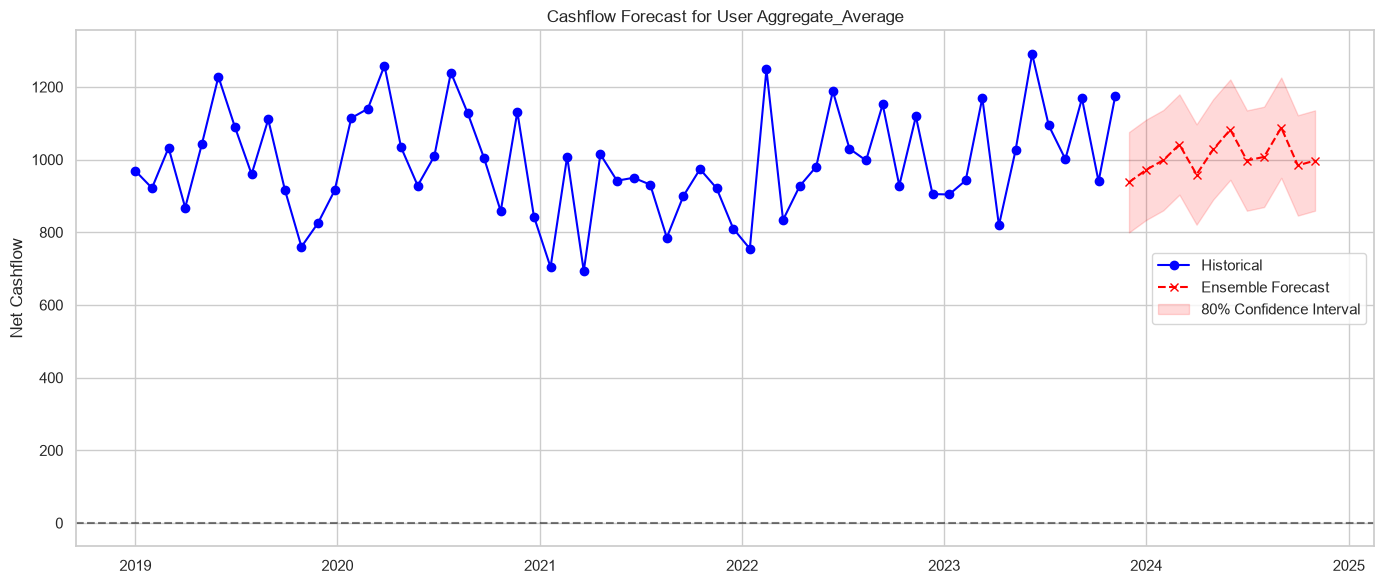

In [9]:
plt.figure(figsize=(14, 6))

# Plot historical
plt.plot(user_df['period'], user_df['net_cashflow'], marker='o', color='blue', label='Historical')

# Plot forecast
plt.plot(forecast_df['period'], forecast_df['forecast'], marker='x', color='red', linestyle='--', label='Ensemble Forecast')

# Plot confidence intervals (from Prophet)
plt.fill_between(
    forecast_df['period'],
    forecast_df['lower_p10'],
    forecast_df['upper_p90'],
    color='red', alpha=0.15, label='80% Confidence Interval'
)

plt.title(f"Cashflow Forecast for User {target_user}")
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.ylabel("Net Cashflow")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Explainability (SHAP)

Since we are using LightGBM, we can see exactly which features (like high rent or low credit score) are driving the predictions.


Top Features Driving Cashflow Predictions:
                  feature  mean_abs_shap
0            total_inflow      67.959847
1  fixed_obligation_ratio      29.115622
2           total_outflow      22.724624
3            savings_rate      15.916998


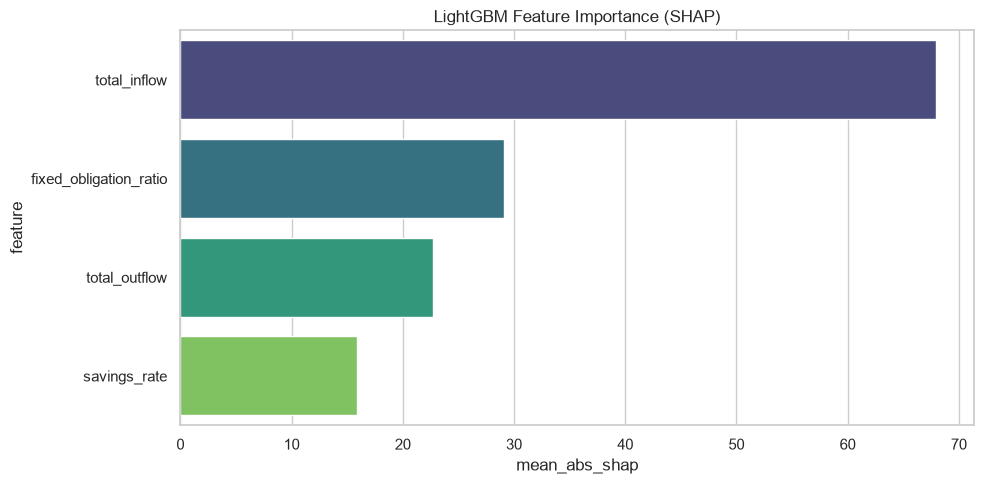

In [10]:
# Print SHAP feature importance
importance_df = forecaster.explain()
print("\nTop Features Driving Cashflow Predictions:")
print(importance_df.head(10))

plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df.head(8), x='mean_abs_shap', y='feature', palette='viridis')
plt.title("LightGBM Feature Importance (SHAP)")
plt.tight_layout()
plt.show()

In [11]:
import sys
from pathlib import Path

# Make sure src is in the python path if not already
src_path = Path("../src").resolve()
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from ml_trainer import run_training_experiment

# Run the full chronological evaluation pipeline
# This will split 60% train / 20% val / 20% test
print(f"Running full evaluation pipeline for {target_user}...")
report = run_training_experiment(
    features_df=user_df,
    entity_id=target_user,
    train_ratio=0.60,
    val_ratio=0.20,
    n_cv_splits=3,
    mlflow_tracking_uri="sqlite:///mlflow.db",
    lgbm_params=best_params  # <--- Use the parameters from tuning
)

print("\n=== Test Set Evaluation Metrics ===")
print(f"RMSE: {report.test_metrics.get('rmse', 0):.2f}")
print(f"MAE:  {report.test_metrics.get('mae', 0):.2f}")
print(f"MAPE: {report.test_metrics.get('mape', 0):.2f}%")
print(f"R2:   {report.test_metrics.get('r2', 0):.4f}")

2026/07/15 13:43:31 INFO mlflow.tracking.fluent: Experiment with name 'cashflow_forecasting' does not exist. Creating a new experiment.


Running full evaluation pipeline for Aggregate_Average...
  CASHFLOW TRAINING EXPERIMENT — Entity: Aggregate_Average
  Split: train=36m  val=12m  test=12m

  ── Walk-Forward CV (3 folds) ──


13:43:32 - cmdstanpy - INFO - Chain [1] start processing
13:43:33 - cmdstanpy - INFO - Chain [1] done processing


  CV Fold 1: MAPE=8.0%  RMSE=81  MAE=74  R²=-5.714  CI%=100.0%


13:43:34 - cmdstanpy - INFO - Chain [1] start processing
13:43:35 - cmdstanpy - INFO - Chain [1] done processing


  CV Fold 2: MAPE=14.8%  RMSE=131  MAE=130  R²=-2.157  CI%=33.3%


13:43:36 - cmdstanpy - INFO - Chain [1] start processing
13:43:36 - cmdstanpy - INFO - Chain [1] done processing


  CV Fold 3: MAPE=21.7%  RMSE=209  MAE=166  R²=-1.315  CI%=33.3%

  ── Training Final Model ──


13:43:37 - cmdstanpy - INFO - Chain [1] start processing
13:43:38 - cmdstanpy - INFO - Chain [1] done processing
13:43:40 - cmdstanpy - INFO - Chain [1] start processing
13:43:41 - cmdstanpy - INFO - Chain [1] done processing



  ── Computing SHAP Importances ──

  MLflow Run ID: 836110123b53474caa42759d24962162

════════════════════════════════════════════════════════════
  CASHFLOW FORECASTER — TRAINING REPORT
════════════════════════════════════════════════════════════
  MLflow Run ID : 836110123b53474caa42759d24962162
  Train months  : 36
  Val months    : 12
  Test months   : 12

  ── Metrics by Split ──
  Train  | MAPE=   8.0%  RMSE=       104  MAE=        78  R²=+0.429  CI%=83.3%
  Val    | MAPE=  12.1%  RMSE=       160  MAE=       127  R²=-0.146  CI%=66.7%
  Test   | MAPE=   9.9%  RMSE=       138  MAE=       108  R²=-0.020  CI%=58.3%
  CV Avg | MAPE=  14.8%  RMSE=       140  MAE=       123  R²=-3.062  CI%=55.6%
════════════════════════════════════════════════════════════

=== Test Set Evaluation Metrics ===
RMSE: 137.84
MAE:  108.13
MAPE: 9.92%
R2:   -0.0196


In [12]:
from IPython.display import display
# Predict for multiple horizons: 3, 6, 9, and 12 months
horizons = [3, 6, 9, 12]
forecasts = {}

for h in horizons:
    print(f"--- Forecasting {h} months ahead ---")
    forecast_df = forecaster.predict(horizon=h)
    forecasts[h] = forecast_df
    
    # Display the results for this horizon
    display(forecast_df.head(h))
    print("\n")


--- Forecasting 3 months ahead ---


,period,forecast,lower_p10,upper_p90,prophet_forecast,lgbm_forecast
0,2023-12-01,937.659059,799.646579,1075.671539,870.407808,1004.91031
1,2024-01-01,971.909955,833.897475,1109.922435,938.909599,1004.91031
2,2024-02-01,998.455382,860.442902,1136.467862,992.000453,1004.91031




--- Forecasting 6 months ahead ---


,period,forecast,lower_p10,upper_p90,prophet_forecast,lgbm_forecast
0,2023-12-01,937.659059,799.646579,1075.671539,870.407808,1004.91031
1,2024-01-01,971.909955,833.897475,1109.922435,938.909599,1004.91031
2,2024-02-01,998.455382,860.442902,1136.467862,992.000453,1004.91031
3,2024-03-01,1041.432693,903.420214,1179.445173,1077.955076,1004.91031
4,2024-04-01,958.932563,820.920084,1096.945043,912.954816,1004.91031
5,2024-05-01,1027.871645,889.859165,1165.884125,1050.832980,1004.91031




--- Forecasting 9 months ahead ---


,period,forecast,lower_p10,upper_p90,prophet_forecast,lgbm_forecast
0,2023-12-01,937.659059,799.646579,1075.671539,870.407808,1004.91031
1,2024-01-01,971.909955,833.897475,1109.922435,938.909599,1004.91031
2,2024-02-01,998.455382,860.442902,1136.467862,992.000453,1004.91031
3,2024-03-01,1041.432693,903.420214,1179.445173,1077.955076,1004.91031
4,2024-04-01,958.932563,820.920084,1096.945043,912.954816,1004.91031
5,2024-05-01,1027.871645,889.859165,1165.884125,1050.832980,1004.91031
6,2024-06-01,1082.427270,944.414790,1220.439750,1159.944229,1004.91031
7,2024-07-01,997.372363,859.359883,1135.384843,989.834415,1004.91031
8,2024-08-01,1007.494980,869.482500,1145.507459,1010.079649,1004.91031




--- Forecasting 12 months ahead ---


,period,forecast,lower_p10,upper_p90,prophet_forecast,lgbm_forecast
0,2023-12-01,937.659059,799.646579,1075.671539,870.407808,1004.91031
1,2024-01-01,971.909955,833.897475,1109.922435,938.909599,1004.91031
2,2024-02-01,998.455382,860.442902,1136.467862,992.000453,1004.91031
3,2024-03-01,1041.432693,903.420214,1179.445173,1077.955076,1004.91031
4,2024-04-01,958.932563,820.920084,1096.945043,912.954816,1004.91031
5,2024-05-01,1027.871645,889.859165,1165.884125,1050.832980,1004.91031
6,2024-06-01,1082.427270,944.414790,1220.439750,1159.944229,1004.91031
7,2024-07-01,997.372363,859.359883,1135.384843,989.834415,1004.91031
8,2024-08-01,1007.494980,869.482500,1145.507459,1010.079649,1004.91031
9,2024-09-01,1087.761499,949.749019,1225.773979,1170.612687,1004.91031
